In [1]:
# %% Imports
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.signal import windows
import os
%matplotlib widget

plt.rc('font', family='serif')
plt.rc('xtick', labelsize=14)
plt.rc('ytick', labelsize=14)
plt.rc('axes', titlesize=16, labelsize=16)
plt.rc('legend', fontsize=14)
plt.rc('figure', titlesize=18)


In [41]:
"""
generate SYNTHETIC TOF data for figure layout only.
Nothing here is a measurement. Replace before anything goes in the paper.
"""
import numpy as np
import pandas as pd
from pathlib import Path

# ---------------------------------------------------------------- knobs
# All INVENTED. Placeholders so the figure has something to draw.
SIGMA_FRAC_V   = 0.0025   # [NUM?] fractional shot-to-shot scatter in launch velocity
SIGMA_H0       = 1.0e-3   # [NUM?] m, random part of starting-height uncertainty
SIGMA_T_UP     = 0.3e-3   # [NUM?] s, centroid uncertainty, up-going crossing
SIGMA_T_DOWN   = 1.5e-3   # [NUM?] s, down-going: dilute 8 uK cloud, weaker signal
N_SHOTS        = 10       # shots per track speed
SEED           = 20260714

# ------------------------------------------------------------- geometry
G       = 9.81               # m/s^2
ALPHA   = 16.0 * np.sqrt(2)  # 16 bounces-worth * sqrt(2) from the 45 deg beams
H_PROBE = 0.25               # m, fluorescence probe height
V_TRACK_MAX_UP   = 300.0     # mm/s
V_TRACK_MAX_DOWN = 165.0     # mm/s, above this the cloud hits the top of the tower

def t_cross(v, h, g=G):
    """Both roots of h = v t - g t^2 / 2. NaN if the cloud never reaches h."""
    disc = v**2 - 2*g*h
    ok   = disc > 0
    root = np.sqrt(np.where(ok, disc, np.nan))
    return (v - root)/g, (v + root)/g          # t_up, t_down

# minimum track speed that reaches the probe at all
V_TRACK_MIN = np.sqrt(2*G*H_PROBE)/ALPHA * 1e3      # mm/s

# ---------------------------------------------------------------- scan
# dense at the low end: dt/dv is ~20x larger there, that is where the figure bites
v_track = np.concatenate([
    np.arange(105, 170, 5.0),
    np.arange(170, 305, 10.0),
])

rng  = np.random.default_rng(SEED)
rows = []
for vt in v_track:
    for direction, sig_t in (("up", SIGMA_T_UP), ("down", SIGMA_T_DOWN)):
        if direction == "down" and vt > V_TRACK_MAX_DOWN:
            continue
        for shot in range(N_SHOTS):
            v_l = ALPHA * (vt*1e-3) * (1 + rng.normal(0, SIGMA_FRAC_V))
            h   = H_PROBE + rng.normal(0, SIGMA_H0)
            tu, td = t_cross(v_l, h)
            t = tu if direction == "up" else td
            if not np.isfinite(t):
                continue
            rows.append(dict(v_track_mm_s=vt, direction=direction, shot=shot,
                             t_s=t + rng.normal(0, sig_t)))

df = pd.DataFrame(rows)
out = Path("data_gitignore"); out.mkdir(exist_ok=True)
df.to_csv(out/"tof_synthetic.csv", index=False)

print(f"alpha = {ALPHA:.3f}   v_track cutoff at {H_PROBE*100:.0f} cm = "
      f"{V_TRACK_MIN:.1f} mm/s")
print(f"{len(df)} rows -> {out/'tof_synthetic.csv'}")

alpha = 22.627   v_track cutoff at 25 cm = 97.9 mm/s
400 rows -> data_gitignore/tof_synthetic.csv


Text(0.5, 0.5, 'SYNTHETIC DATA')

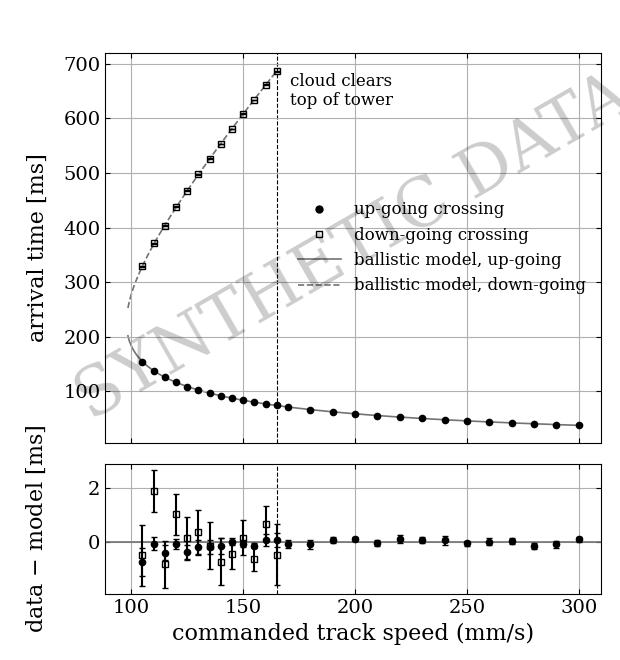

In [44]:
"""
Cell 2 -- read the file, draft the figure.
Top:    arrival time vs commanded track speed, both crossings, kinematic model.
Bottom: residual, data - model, in ms.
"""
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pathlib import Path

G       = 9.81
ALPHA   = 16.0 * np.sqrt(2)
H_PROBE = 0.25
V_TRACK_MAX_DOWN = 165.0

df = pd.read_csv(Path("data_gitignore")/"tof_synthetic.csv")

def t_cross(v, h=H_PROBE, g=G):
    disc = v**2 - 2*g*h
    root = np.sqrt(np.where(disc > 0, disc, np.nan))
    return (v - root)/g, (v + root)/g

def t_model(v_track_mm_s, direction):
    tu, td = t_cross(ALPHA * np.asarray(v_track_mm_s, float)*1e-3)
    return tu if direction == "up" else td

# ------------------------------------------------- mean and SEM per setting
g_ = df.groupby(["direction", "v_track_mm_s"])["t_s"]
stat = g_.agg(t_mean="mean", t_sd="std", n="count").reset_index()
stat["t_sem"]  = stat.t_sd / np.sqrt(stat.n)
stat["t_th"]   = [t_model(v, d) for v, d in zip(stat.v_track_mm_s, stat.direction)]
stat["res_ms"] = (stat.t_mean - stat.t_th)*1e3          # data - model

# ------------------------------------------------------------------ curves
vt_up  = np.linspace(98.5, 300.0, 500)
vt_dn  = np.linspace(98.5, V_TRACK_MAX_DOWN, 500)
tu     = t_model(vt_up, "up")
td     = t_model(vt_dn, "down")

# ------------------------------------------------------------------- plot
fig, (ax, axr) = plt.subplots(
    2, 1, figsize=(6.2, 6.6), sharex=True,
    gridspec_kw=dict(height_ratios=[3, 1], hspace=0.08))
fig.subplots_adjust(left=0.17, right=0.97, top=0.92, bottom=0.10)

MODEL = dict(color="0.45", lw=1.2)
ax.plot(vt_up, tu*1e3, "-",  zorder=1, **MODEL)
ax.plot(vt_dn, td*1e3, "--", zorder=1, **MODEL)

mk = dict(up=dict(marker="o", mfc="k"), down=dict(marker="s", mfc="none"))
for d in ("up", "down"):
    s = stat[stat.direction == d]
    for a, y, ye in ((ax,  s.t_mean*1e3, s.t_sem*1e3),
                     (axr, s.res_ms,     s.t_sem*1e3)):
        a.errorbar(s.v_track_mm_s, y, yerr=ye, ls="none", ms=4.5,
                   color="k", mec="k", ecolor="k", capsize=2, zorder=3, **mk[d])

# tower cutoff, annotated low, in the gap between the two branches
ax.axvline(V_TRACK_MAX_DOWN,  color="k", lw=0.8, zorder=0, linestyle = '--')
axr.axvline(V_TRACK_MAX_DOWN, color="k", lw=0.8, zorder=0, linestyle = '--')
ax.text(V_TRACK_MAX_DOWN + 6, 650, "cloud clears\ntop of tower",
        fontsize=12, rotation = -0, color="k", va="center", ha="left")

axr.axhline(0, color="0.45", lw=1.2)

# legend: make it unmistakable that the grey curves are a model, not a fit
handles = [
    Line2D([], [], ls="none", marker="o", mfc="k",    mec="k", color="k", ms=5,
           label="up-going crossing"),
    Line2D([], [], ls="none", marker="s", mfc="none", mec="k", color="k", ms=5,
           label="down-going crossing"),
    Line2D([], [], ls="-",  label="ballistic model, up-going", **MODEL),
    Line2D([], [], ls="--", label="ballistic model, down-going", **MODEL),
]
ax.legend(handles=handles, frameon=False, fontsize=12, loc="center right",
          handlelength=2.6,
          title_fontsize=12, alignment="left")

ax.set_ylabel("arrival time [ms]")
axr.set_xlabel("commanded track speed (mm/s)")
axr.set_ylabel("data $-$ model [ms]")
ax.yaxis.set_label_coords(-0.115, 0.5)
axr.yaxis.set_label_coords(-0.115, 0.5)
ax.grid()
axr.grid()
for a in (ax, axr):
    a.tick_params(direction="in", top=True, right=True)

ax.text(0.5, 0.5, "SYNTHETIC DATA", transform=ax.transAxes,
        fontsize=48, color="k", alpha=0.2,
        ha="center", va="center", rotation=30, zorder=10)
#fig.suptitle("SYNTHETIC DATA", fontsize=16, color="k", y=0.965)
#fig.savefig("tof_draft.png", dpi=200)
#print(stat.groupby("direction").res_ms.agg(["mean", "std", "min", "max"]))